In [1]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/pratyaydas01/era5-winds/combined_all_era5_winds (2).csv')

In [2]:
df.head()

,time,speed_80m,dir_80m
0,01-01-1985 00:00,4.139234,20.042175
1,01-01-1985 01:00,3.941339,24.182251
2,01-01-1985 02:00,3.945018,29.795410
3,01-01-1985 03:00,4.036211,35.188293
4,01-01-1985 04:00,3.748477,41.227050


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262968 entries, 0 to 262967
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   time       262968 non-null  object 
 1   speed_80m  262968 non-null  float64
 2   dir_80m    262968 non-null  float64
dtypes: float64(2), object(1)
memory usage: 6.0+ MB


In [4]:
df.isnull().sum()

time         0
speed_80m    0
dir_80m      0
dtype: int64

In [5]:
# Convert time column to datetime
df['time'] = pd.to_datetime(df['time'], format='%d-%m-%Y %H:%M')

# Set time as index
df.set_index('time', inplace=True)

In [6]:
df.head()

,speed_80m,dir_80m
time,,
1985-01-01 00:00:00,4.139234,20.042175
1985-01-01 01:00:00,3.941339,24.182251
1985-01-01 02:00:00,3.945018,29.795410
1985-01-01 03:00:00,4.036211,35.188293
1985-01-01 04:00:00,3.748477,41.227050


In [7]:
df.index

DatetimeIndex(['1985-01-01 00:00:00', '1985-01-01 01:00:00',
               '1985-01-01 02:00:00', '1985-01-01 03:00:00',
               '1985-01-01 04:00:00', '1985-01-01 05:00:00',
               '1985-01-01 06:00:00', '1985-01-01 07:00:00',
               '1985-01-01 08:00:00', '1985-01-01 09:00:00',
               ...
               '2014-12-31 14:00:00', '2014-12-31 15:00:00',
               '2014-12-31 16:00:00', '2014-12-31 17:00:00',
               '2014-12-31 18:00:00', '2014-12-31 19:00:00',
               '2014-12-31 20:00:00', '2014-12-31 21:00:00',
               '2014-12-31 22:00:00', '2014-12-31 23:00:00'],
              dtype='datetime64[ns]', name='time', length=262968, freq=None)

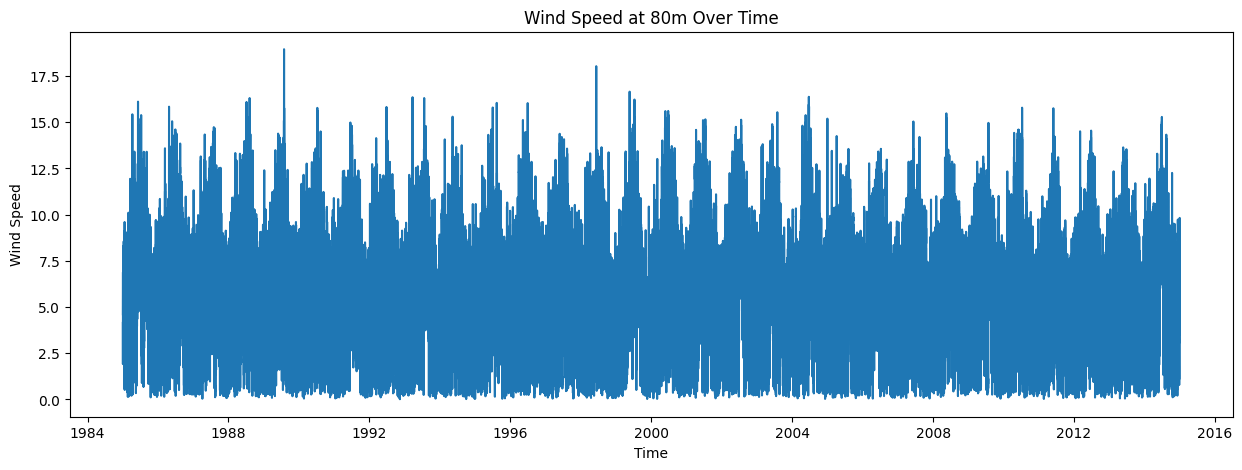

In [8]:
import matplotlib.pyplot as plt

# Plot wind speed
plt.figure(figsize=(15,5))
plt.plot(df['speed_80m'])

plt.title('Wind Speed at 80m Over Time')
plt.xlabel('Time')
plt.ylabel('Wind Speed')

plt.show()

* Strong repeating fluctuations over years
* No obvious long-term upward/downward trend
* Clear cyclical behavior → likely seasonality
* Hourly data is very noisy

In [9]:
# Daily average wind speed
daily_df = df['speed_80m'].resample('D').mean()

# Check output
print(daily_df.head())
print(daily_df.shape)

time
1985-01-01    3.889954
1985-01-02    5.870372
1985-01-03    5.891763
1985-01-04    4.888502
1985-01-05    5.555732
Freq: D, Name: speed_80m, dtype: float64
(10957,)


In [10]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test
result = adfuller(daily_df)

# Print results
print('ADF Statistic:', result[0])
print('p-value:', result[1])

print('\nCritical Values:')
for key, value in result[4].items():
    print(f'{key}: {value}')

ADF Statistic: -8.978786944178276
p-value: 7.406714575197872e-15

Critical Values:
1%: -3.4309487036285113
5%: -2.8618045938569296
10%: -2.5669108381800188


<Figure size 1500x500 with 0 Axes>

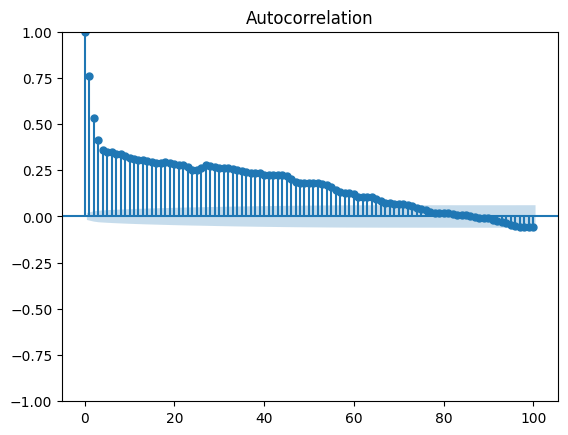

In [11]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plot_acf(daily_df, lags=100)

plt.show()

<Figure size 1500x500 with 0 Axes>

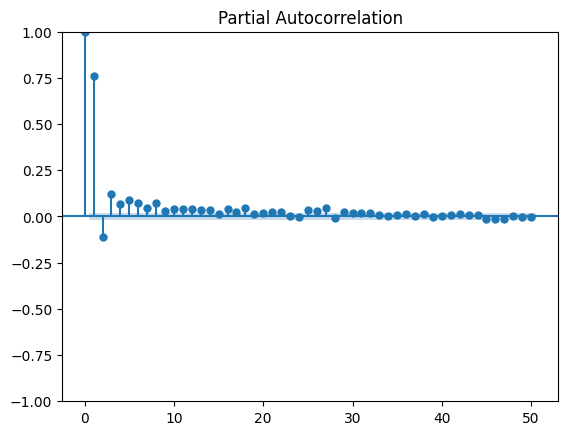

In [12]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plot_pacf(daily_df, lags=50)

plt.show()

* train: 1985 → 2012
* test: 2013 → 2014

In [13]:
# Train-test split

train = daily_df[:'2012']
test = daily_df['2013':]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain range:")
print(train.index.min(), "to", train.index.max())

print("\nTest range:")
print(test.index.min(), "to", test.index.max())

Train shape: (10227,)
Test shape: (730,)

Train range:
1985-01-01 00:00:00 to 2012-12-31 00:00:00

Test range:
2013-01-01 00:00:00 to 2014-12-31 00:00:00


#### ARIMA

In [14]:
from statsmodels.tsa.arima.model import ARIMA

# Build model
model = ARIMA(train, order=(1,0,1))

# Train model
model_fit = model.fit()

# Print summary
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:              speed_80m   No. Observations:                10227
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -18919.395
Date:                Sat, 23 May 2026   AIC                          37846.789
Time:                        10:58:03   BIC                          37875.721
Sample:                    01-01-1985   HQIC                         37856.572
                         - 12-31-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.9025      0.057    102.748      0.000       5.790       6.015
ar.L1          0.6789      0.010     70.161      0.000       0.660       0.698
ma.L1          0.1908      0.011     16.622      0.0

In [15]:
# Forecast for test period
forecast = model_fit.forecast(steps=len(test))

# Preview predictions
print(forecast.head())

2013-01-01    5.131855
2013-01-02    5.379318
2013-01-03    5.547318
2013-01-04    5.661373
2013-01-05    5.738803
Freq: D, Name: predicted_mean, dtype: float64


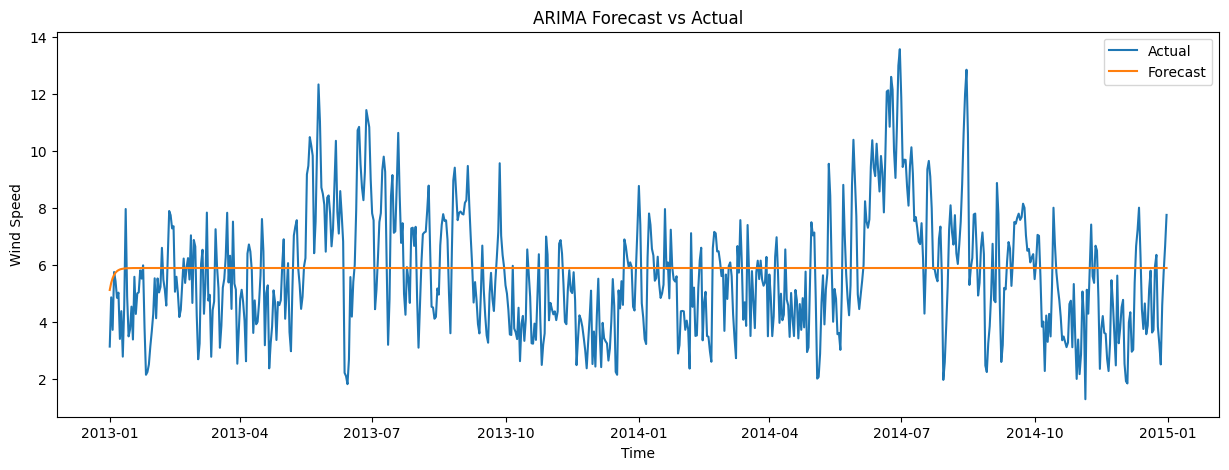

In [16]:
plt.figure(figsize=(15,5))

# Actual test data
plt.plot(test.index, test, label='Actual')

# Forecasted data
plt.plot(test.index, forecast, label='Forecast')

plt.title('ARIMA Forecast vs Actual')
plt.xlabel('Time')
plt.ylabel('Wind Speed')

plt.legend()

plt.show()

##### ARIMA Struggled
###### Wind data is usually:
*     highly seasonal
*     noisy
*     nonlinear
*     influenced by long cycles

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# RMSE
rmse = np.sqrt(mean_squared_error(test, forecast))

# MAE
mae = mean_absolute_error(test, forecast)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 2.140649672932247
MAE: 1.7174518261861602


#### SARIMA

In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Build SARIMA model
sarima_model = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,0,1,7)
)

# Train model
sarima_fit = sarima_model.fit()

# Summary
print(sarima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                     
Dep. Variable:                         speed_80m   No. Observations:                10227
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood              -18943.257
Date:                           Sat, 23 May 2026   AIC                          37896.514
Time:                                   10:58:16   BIC                          37932.678
Sample:                               01-01-1985   HQIC                         37908.741
                                    - 12-31-2012                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6804      0.010     70.168      0.000       0.661       0.699
ma.L1          0.1884      0.011     16.464

#### Convert Daily Data to Monthly Data

In [19]:
# Monthly average wind speed
monthly_df = daily_df.resample('M').mean()

print(monthly_df.head())
print(monthly_df.shape)

time
1985-01-31    5.625988
1985-02-28    4.706418
1985-03-31    4.948393
1985-04-30    6.334781
1985-05-31    6.773374
Freq: ME, Name: speed_80m, dtype: float64
(360,)


/tmp/ipykernel_57/410212563.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_df = daily_df.resample('M').mean()


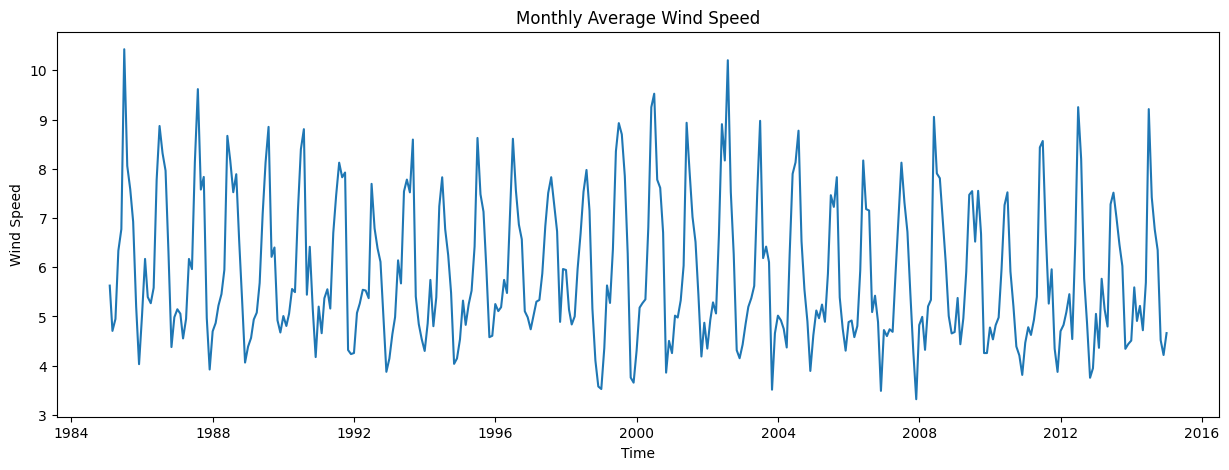

In [20]:
plt.figure(figsize=(15,5))

plt.plot(monthly_df)

plt.title('Monthly Average Wind Speed')
plt.xlabel('Time')
plt.ylabel('Wind Speed')

plt.show()

In [21]:
# Monthly train-test split

monthly_train = monthly_df[:'2012']
monthly_test = monthly_df['2013':]

print("Train shape:", monthly_train.shape)
print("Test shape:", monthly_test.shape)

print("\nTrain range:")
print(monthly_train.index.min(), "to", monthly_train.index.max())

print("\nTest range:")
print(monthly_test.index.min(), "to", monthly_test.index.max())

Train shape: (336,)
Test shape: (24,)

Train range:
1985-01-31 00:00:00 to 2012-12-31 00:00:00

Test range:
2013-01-31 00:00:00 to 2014-12-31 00:00:00


In [22]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Build SARIMA model
monthly_sarima = SARIMAX(
    monthly_train,
    order=(1,0,1),
    seasonal_order=(1,1,1,12)
)

# Train model
monthly_sarima_fit = monthly_sarima.fit()

# Summary
print(monthly_sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          speed_80m   No. Observations:                  336
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -333.948
Date:                            Sat, 23 May 2026   AIC                            677.896
Time:                                    10:58:17   BIC                            696.800
Sample:                                01-31-1985   HQIC                           685.441
                                     - 12-31-2012                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4958      0.211      2.352      0.019       0.083       0.909
ma.L1         -0.2862      0.226   

In [23]:
# Forecast
monthly_forecast = monthly_sarima_fit.forecast(steps=len(monthly_test))

print(monthly_forecast.head())

2013-01-31    4.939571
2013-02-28    4.814182
2013-03-31    5.072324
2013-04-30    5.614510
2013-05-31    7.646819
Freq: ME, Name: predicted_mean, dtype: float64


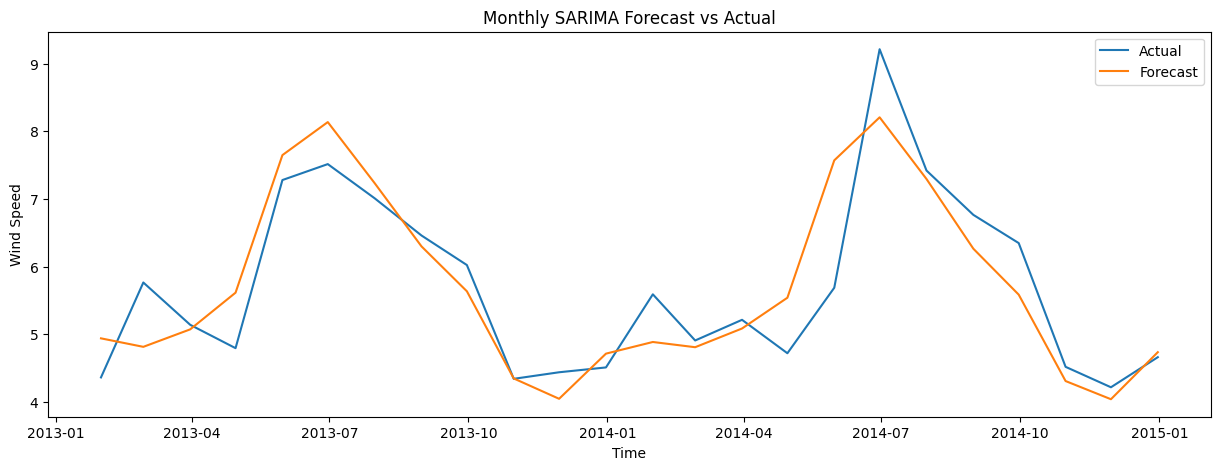

In [24]:
plt.figure(figsize=(15,5))

# Actual values
plt.plot(monthly_test.index, monthly_test, label='Actual')

# Forecast values
plt.plot(monthly_test.index, monthly_forecast, label='Forecast')

plt.title('Monthly SARIMA Forecast vs Actual')
plt.xlabel('Time')
plt.ylabel('Wind Speed')

plt.legend()

plt.show()

#### Train-Test on entire dataset

In [25]:
# Train until end of 2013
train_2013 = monthly_df[:'2013']

# Test only 2014
test_2014 = monthly_df['2014':]

print("Train shape:", train_2013.shape)
print("Test shape:", test_2014.shape)

print("\nTrain range:")
print(train_2013.index.min(), "to", train_2013.index.max())

print("\nTest range:")
print(test_2014.index.min(), "to", test_2014.index.max())

Train shape: (348,)
Test shape: (12,)

Train range:
1985-01-31 00:00:00 to 2013-12-31 00:00:00

Test range:
2014-01-31 00:00:00 to 2014-12-31 00:00:00


In [26]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Train SARIMA model
model_2013 = SARIMAX(
    train_2013,
    order=(1,0,1),
    seasonal_order=(1,1,1,12)
)

# Fit model
model_2013_fit = model_2013.fit()

# Show summary
print(model_2013_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          speed_80m   No. Observations:                  348
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -343.426
Date:                            Sat, 23 May 2026   AIC                            696.852
Time:                                    10:58:19   BIC                            715.937
Sample:                                01-31-1985   HQIC                           704.460
                                     - 12-31-2013                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4971      0.209      2.376      0.018       0.087       0.907
ma.L1         -0.2913      0.224   

In [27]:
# Forecast 12 months for 2014
forecast_2014 = model_2013_fit.forecast(steps=12)

print(forecast_2014)

2014-01-31    4.803645
2014-02-28    4.916963
2014-03-31    5.089735
2014-04-30    5.454305
2014-05-31    7.528916
2014-06-30    8.125251
2014-07-31    7.278535
2014-08-31    6.306359
2014-09-30    5.645224
2014-10-31    4.314992
2014-11-30    4.093295
2014-12-31    4.707992
Freq: ME, Name: predicted_mean, dtype: float64


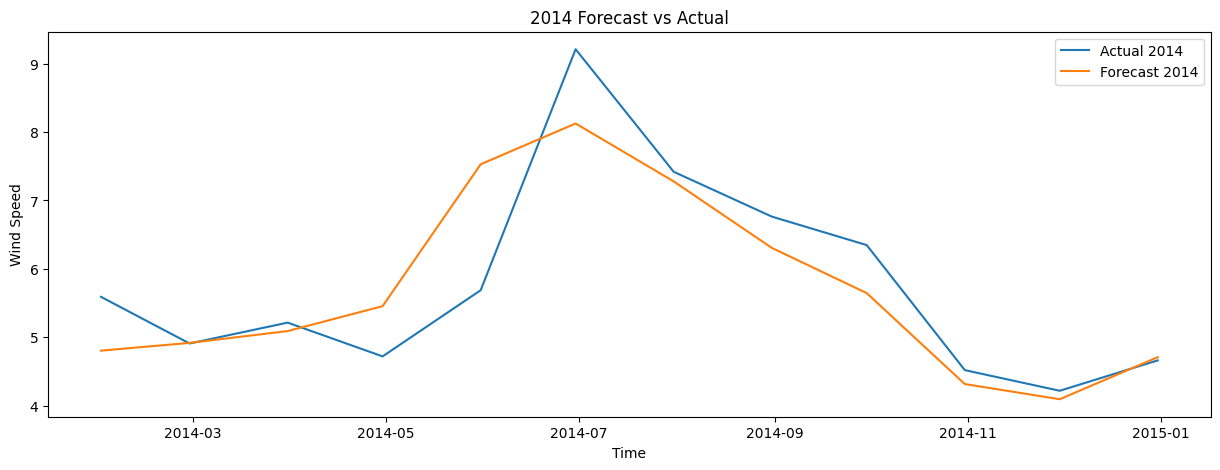

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

# Actual 2014 values
plt.plot(test_2014.index, test_2014, label='Actual 2014')

# Forecasted values
plt.plot(test_2014.index, forecast_2014, label='Forecast 2014')

plt.title('2014 Forecast vs Actual')
plt.xlabel('Time')
plt.ylabel('Wind Speed')

plt.legend()

plt.show()

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test_2014, forecast_2014))
mae = mean_absolute_error(test_2014, forecast_2014)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 0.7374410430925042
MAE: 0.5212830272631301


In [30]:
# Final model on all available data

final_model = SARIMAX(
    monthly_df,
    order=(1,0,1),
    seasonal_order=(1,1,1,12)
)

# Fit final model
final_model_fit = final_model.fit()

print(final_model_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          speed_80m   No. Observations:                  360
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -357.407
Date:                            Sat, 23 May 2026   AIC                            724.813
Time:                                    10:58:20   BIC                            744.074
Sample:                                01-31-1985   HQIC                           732.482
                                     - 12-31-2014                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4796      0.221      2.166      0.030       0.046       0.913
ma.L1         -0.2822      0.236   

In [31]:
# Forecast next 144 months (2015–2026)

future_forecast = final_model_fit.forecast(steps=144)

print(future_forecast.head())
print(future_forecast.tail())

2015-01-31    4.886940
2015-02-28    4.974302
2015-03-31    5.111604
2015-04-30    5.318815
2015-05-31    7.291746
Freq: ME, Name: predicted_mean, dtype: float64
2026-08-31    6.377601
2026-09-30    5.777052
2026-10-31    4.346718
2026-11-30    4.129951
2026-12-31    4.690663
Freq: ME, Name: predicted_mean, dtype: float64


In [32]:
# Create future monthly dates

future_dates = pd.date_range(
    start='2015-01-31',
    periods=144,
    freq='M'
)

# Convert forecast to dataframe
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecast_Wind_Speed': future_forecast.values
})

print(forecast_df.head())

        Date  Forecast_Wind_Speed
0 2015-01-31             4.886940
1 2015-02-28             4.974302
2 2015-03-31             5.111604
3 2015-04-30             5.318815
4 2015-05-31             7.291746


/tmp/ipykernel_57/2360375224.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(


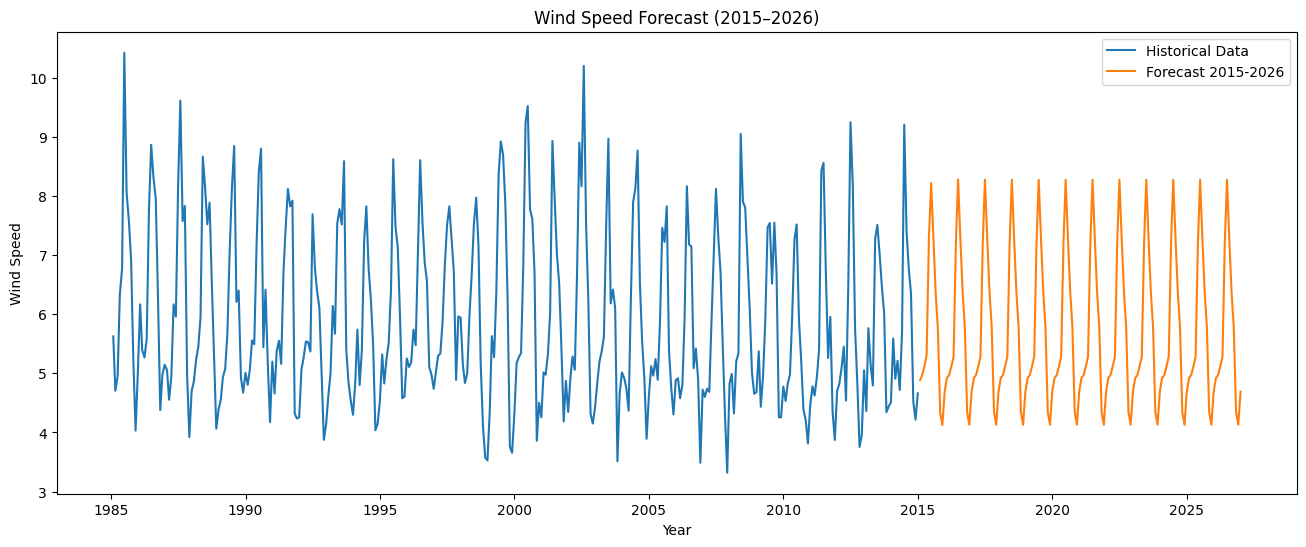

In [33]:
plt.figure(figsize=(16,6))

# Historical data
plt.plot(monthly_df.index, monthly_df, label='Historical Data')

# Forecast data
plt.plot(
    forecast_df['Date'],
    forecast_df['Forecast_Wind_Speed'],
    label='Forecast 2015-2026'
)

plt.title('Wind Speed Forecast (2015–2026)')
plt.xlabel('Year')
plt.ylabel('Wind Speed')

plt.legend()

plt.show()

#### Prophet (New Model)

In [34]:
!pip install prophet

In [35]:
from prophet import Prophet

In [36]:
# Convert monthly data into Prophet format

prophet_df = monthly_df.reset_index()

# Rename columns
prophet_df.columns = ['ds', 'y']

print(prophet_df.head())

          ds         y
0 1985-01-31  5.625988
1 1985-02-28  4.706418
2 1985-03-31  4.948393
3 1985-04-30  6.334781
4 1985-05-31  6.773374


In [37]:
# Train until 2013
prophet_train = prophet_df[prophet_df['ds'] < '2014-01-01']

# Test = 2014
prophet_test = prophet_df[prophet_df['ds'] >= '2014-01-01']

print(prophet_train.shape)
print(prophet_test.shape)

(348, 2)
(12, 2)


In [38]:
from prophet import Prophet

# Create model
prophet_model = Prophet(
    yearly_seasonality=True
)

# Train model
prophet_model.fit(prophet_train)

10:58:27 - cmdstanpy - INFO - Chain [1] start processing
10:58:27 - cmdstanpy - INFO - Chain [1] done processing


In [39]:
# Create dataframe for future dates
future_2014 = prophet_model.make_future_dataframe(
    periods=12,
    freq='M'
)

# Predict
forecast_2014 = prophet_model.predict(future_2014)

# Show prediction columns
forecast_2014[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
348,2014-01-31,4.608795,3.809159,5.379447
349,2014-02-28,4.706382,3.900909,5.479334
350,2014-03-31,4.837473,4.046014,5.568022
351,2014-04-30,5.415229,4.555257,6.273046
352,2014-05-31,7.039123,6.198118,7.808243
353,2014-06-30,7.866753,7.042687,8.690853
354,2014-07-31,7.408026,6.635565,8.215176
355,2014-08-31,6.528622,5.785495,7.361579
356,2014-09-30,5.811570,5.012789,6.646404
357,2014-10-31,4.136476,3.313288,5.006178


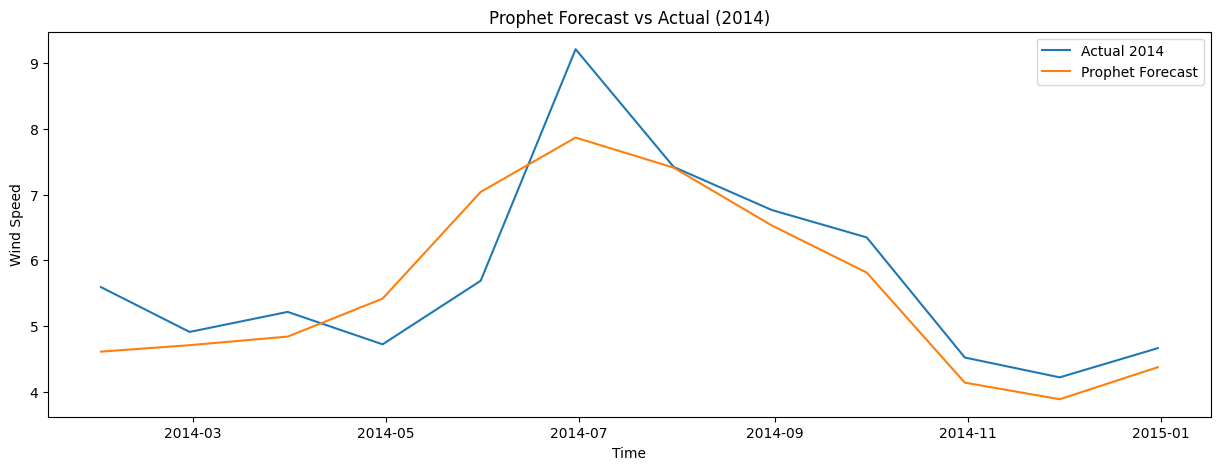

In [40]:
plt.figure(figsize=(15,5))

# Actual 2014
plt.plot(
    prophet_test['ds'],
    prophet_test['y'],
    label='Actual 2014'
)

# Forecast 2014
plt.plot(
    forecast_2014['ds'].tail(12),
    forecast_2014['yhat'].tail(12),
    label='Prophet Forecast'
)

plt.title('Prophet Forecast vs Actual (2014)')
plt.xlabel('Time')
plt.ylabel('Wind Speed')

plt.legend()

plt.show()

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Actual values
actual = prophet_test['y'].values

# Predicted values
predicted = forecast_2014['yhat'].tail(12).values

# Metrics
rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 0.7040390939518613
MAE: 0.561550633809256


In [42]:
# Train Prophet on ALL available data

final_prophet = Prophet(
    yearly_seasonality=True
)

final_prophet.fit(prophet_df)

10:58:28 - cmdstanpy - INFO - Chain [1] start processing
10:58:28 - cmdstanpy - INFO - Chain [1] done processing


In [43]:
# Create future dates

future = final_prophet.make_future_dataframe(
    periods=144,
    freq='M'
)

# Predict future
future_forecast = final_prophet.predict(future)

# Show last predictions
future_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
499,2026-08-31,6.330983,5.514538,7.107070
500,2026-09-30,5.614083,4.813726,6.461100
501,2026-10-31,3.952395,3.117071,4.812998
502,2026-11-30,3.697955,2.919153,4.510155
503,2026-12-31,4.173351,3.367735,4.947766


In [44]:
# Keep only future dates (2015 onwards)

future_predictions = future_forecast[
    future_forecast['ds'] >= '2015-01-01'
]

print(future_predictions[['ds', 'yhat']].head())
print(future_predictions[['ds', 'yhat']].tail())

            ds      yhat
360 2015-01-31  4.681390
361 2015-02-28  4.752773
362 2015-03-31  4.838638
363 2015-04-30  5.433130
364 2015-05-31  6.929454
            ds      yhat
499 2026-08-31  6.330983
500 2026-09-30  5.614083
501 2026-10-31  3.952395
502 2026-11-30  3.697955
503 2026-12-31  4.173351


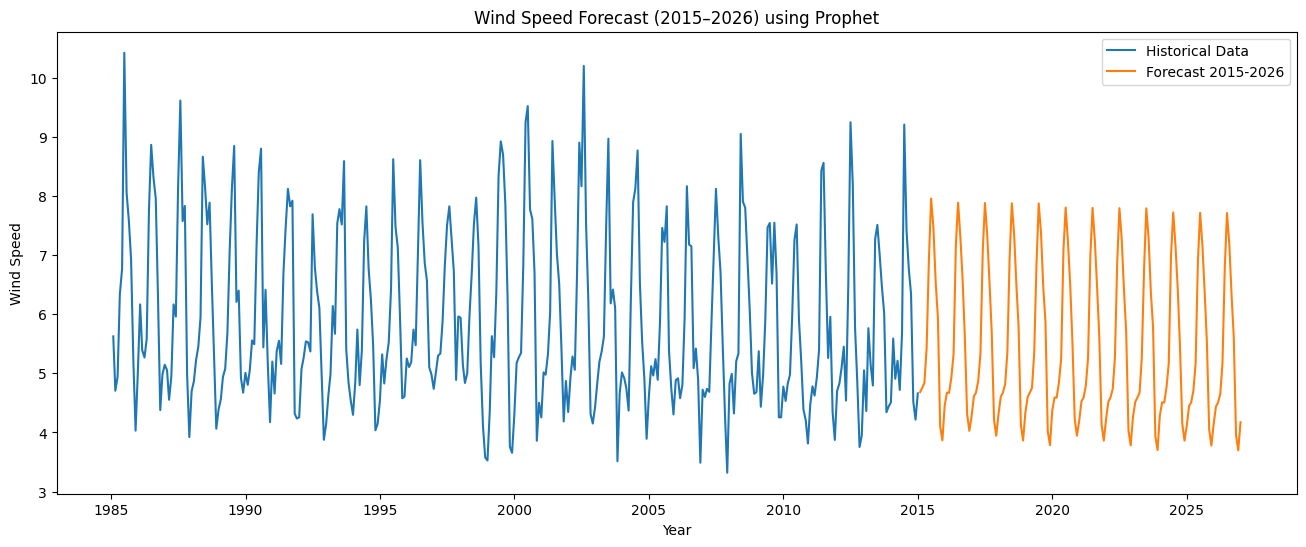

In [45]:
plt.figure(figsize=(16,6))

# Historical data
plt.plot(
    prophet_df['ds'],
    prophet_df['y'],
    label='Historical Data'
)

# Future forecast
plt.plot(
    future_predictions['ds'],
    future_predictions['yhat'],
    label='Forecast 2015-2026'
)

plt.title('Wind Speed Forecast (2015–2026) using Prophet')
plt.xlabel('Year')
plt.ylabel('Wind Speed')

plt.legend()

plt.show()

#### XGBoost (New Model)

In [46]:
!pip install xgboost

In [47]:
# Create a copy
xgb_df = daily_df.to_frame()

# Create lag features
for lag in range(1, 31):
    xgb_df[f'lag_{lag}'] = xgb_df['speed_80m'].shift(lag)

# Remove missing rows
xgb_df.dropna(inplace=True)

print(xgb_df.head())
print(xgb_df.shape)

            speed_80m     lag_1     lag_2     lag_3     lag_4     lag_5  \
time                                                                      
1985-01-31   6.192307  6.539913  5.439794  5.005058  6.566584  6.527392   
1985-02-01   3.521055  6.192307  6.539913  5.439794  5.005058  6.566584   
1985-02-02   3.989175  3.521055  6.192307  6.539913  5.439794  5.005058   
1985-02-03   6.264287  3.989175  3.521055  6.192307  6.539913  5.439794   
1985-02-04   5.951383  6.264287  3.989175  3.521055  6.192307  6.539913   

               lag_6     lag_7     lag_8     lag_9  ...    lag_21    lag_22  \
time                                                ...                       
1985-01-31  4.267123  3.749787  5.417454  7.116821  ...  6.842295  7.153744   
1985-02-01  6.527392  4.267123  3.749787  5.417454  ...  6.260701  6.842295   
1985-02-02  6.566584  6.527392  4.267123  3.749787  ...  4.276474  6.260701   
1985-02-03  5.005058  6.566584  6.527392  4.267123  ...  4.556341  4.276474   


In [48]:
# Train data
train_xgb = xgb_df[xgb_df.index < '2014-01-01']

# Test data
test_xgb = xgb_df[xgb_df.index >= '2014-01-01']

print(train_xgb.shape)
print(test_xgb.shape)

(10562, 31)
(365, 31)


In [49]:
# Features
X_train = train_xgb.drop('speed_80m', axis=1)
X_test = test_xgb.drop('speed_80m', axis=1)

# Target
y_train = train_xgb['speed_80m']
y_test = test_xgb['speed_80m']

print(X_train.shape)
print(X_test.shape)

(10562, 30)
(365, 30)


In [50]:
from xgboost import XGBRegressor

In [51]:
# Create model
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [52]:
# Predict
xgb_predictions = xgb_model.predict(X_test)

print(xgb_predictions[:10])

[5.9534035 7.168243  6.631663  4.145708  4.9713144 4.0847287 4.012858
 5.3270226 6.6722646 6.0439725]


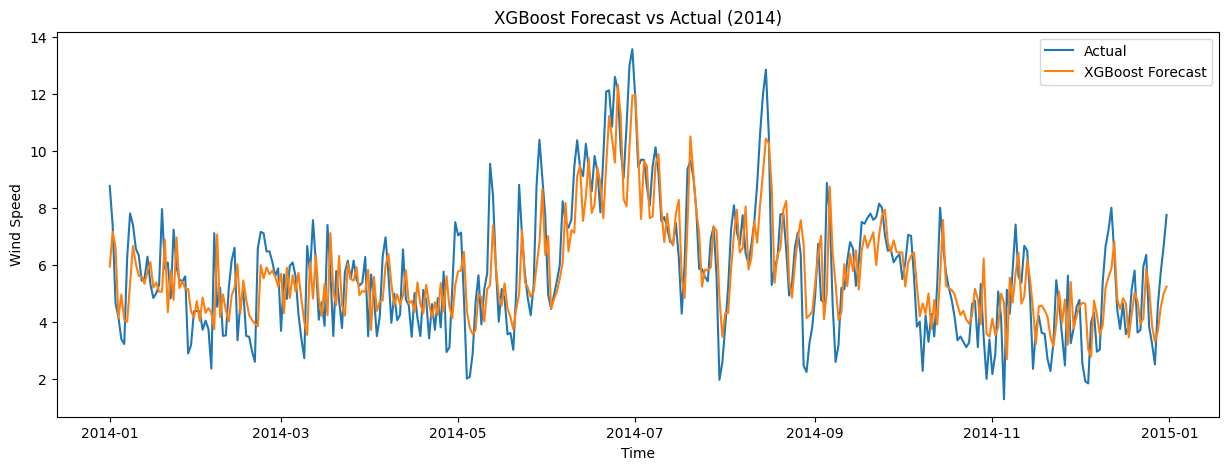

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

# Actual
plt.plot(y_test.index, y_test, label='Actual')

# Predicted
plt.plot(y_test.index, xgb_predictions, label='XGBoost Forecast')

plt.title('XGBoost Forecast vs Actual (2014)')
plt.xlabel('Time')
plt.ylabel('Wind Speed')

plt.legend()

plt.show()

In [54]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
mae = mean_absolute_error(y_test, xgb_predictions)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 1.3781594213073984
MAE: 1.0962822561980872


In [55]:
# Features from ALL data

X_all = xgb_df.drop('speed_80m', axis=1)
y_all = xgb_df['speed_80m']

# Train final model
final_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

final_xgb.fit(X_all, y_all)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [56]:
# Last 30 known daily values

last_sequence = daily_df.values[-30:]

print(last_sequence.shape)

(30,)


In [57]:
future_predictions_xgb = []

current_sequence = last_sequence.copy()

future_days = 4380

for _ in range(future_days):

    # Create input row
    x_input = current_sequence.reshape(1, -1)

    # Predict next value
    next_pred = final_xgb.predict(x_input)[0]

    # Store prediction
    future_predictions_xgb.append(next_pred)

    # Update sequence
    current_sequence = np.append(current_sequence[1:], next_pred)

In [58]:
future_dates = pd.date_range(
    start='2015-01-01',
    periods=future_days,
    freq='D'
)

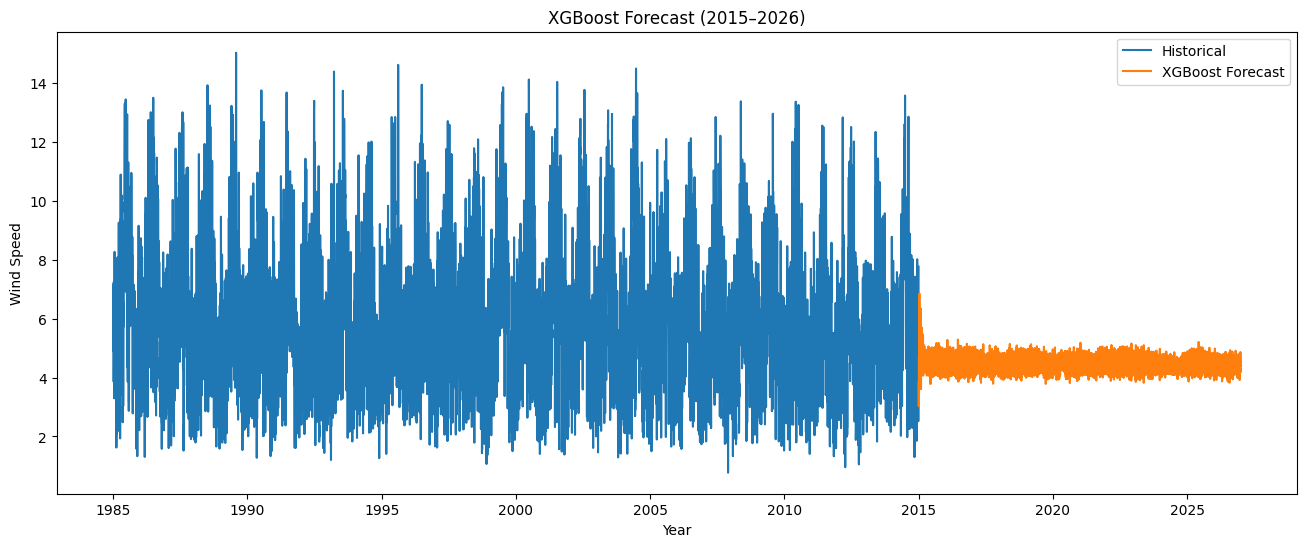

In [59]:
plt.figure(figsize=(16,6))

# Historical
plt.plot(
    daily_df.index,
    daily_df.values,
    label='Historical'
)

# Forecast
plt.plot(
    future_dates,
    future_predictions_xgb,
    label='XGBoost Forecast'
)

plt.title('XGBoost Forecast (2015–2026)')
plt.xlabel('Year')
plt.ylabel('Wind Speed')

plt.legend()

plt.show()

#### LSTM

In [60]:
from sklearn.preprocessing import MinMaxScaler

# Create scaler
scaler = MinMaxScaler()

# Scale daily data
scaled_data = scaler.fit_transform(daily_df.values.reshape(-1,1))

print(scaled_data[:5])

[[0.21886233]
 [0.35763368]
 [0.3591326 ]
 [0.28883236]
 [0.33558631]]


In [61]:
import numpy as np

X = []
y = []

sequence_length = 30

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(10927, 30, 1)
(10927, 1)


In [62]:
# Split index
split_index = int(len(X) * 0.9)

# Train data
X_train = X[:split_index]
y_train = y[:split_index]

# Test data
X_test = X[split_index:]
y_test = y[split_index:]

print(X_train.shape)
print(X_test.shape)

(9834, 30, 1)
(1093, 30, 1)


In [63]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

2026-05-23 10:58:46.319936: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779533926.771215      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779533926.884340      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779533927.899113      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779533927.899195      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779533927.899198      57 computation_placer.cc:177] computation placer alr

In [64]:
# Build model
lstm_model = Sequential()

# LSTM layer
lstm_model.add(
    LSTM(
        units=64,
        return_sequences=False,
        input_shape=(X_train.shape[1], 1)
    )
)

# Dropout for regularization
lstm_model.add(Dropout(0.2))

# Output layer
lstm_model.add(Dense(1))

# Compile model
lstm_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Show architecture
lstm_model.summary()

I0000 00:00:1779533963.048049      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779533963.053902      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
history = lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20


I0000 00:00:1779533966.772779     159 cuda_dnn.cc:529] Loaded cuDNN version 91002


308/308 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0334 - val_loss: 0.0138
Epoch 2/20
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0173 - val_loss: 0.0121
Epoch 3/20
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0147 - val_loss: 0.0100
Epoch 4/20
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0123 - val_loss: 0.0091
Epoch 5/20
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0119 - val_loss: 0.0091
Epoch 6/20
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0117 - val_loss: 0.0090
Epoch 7/20
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0120 - val_loss: 0.0092
Epoch 8/20
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0111 - val_loss: 0.0090
Epoch 9/20
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0115 - val_loss: 0.0089
Epoch 10/20
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0114 - val_loss: 0.0092
Epoch 11/20
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0115 - val_loss: 0.0091
Epoch 12/20
308/308 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.

In [66]:
# Predict on test set
lstm_predictions = lstm_model.predict(X_test)

print(lstm_predictions[:5])

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
[[0.21745218]
 [0.24693936]
 [0.23605894]
 [0.27722254]
 [0.27768004]]


In [67]:
# Inverse transform predictions
lstm_predictions = scaler.inverse_transform(lstm_predictions)

# Inverse transform actual values
y_test_actual = scaler.inverse_transform(y_test)

print(lstm_predictions[:5])
print(y_test_actual[:5])

[[3.8698294]
 [4.290643 ]
 [4.135368 ]
 [4.7228174]
 [4.7293463]]
[[3.90423705]
 [3.74700315]
 [4.93522308]
 [5.15545924]
 [6.62084703]]


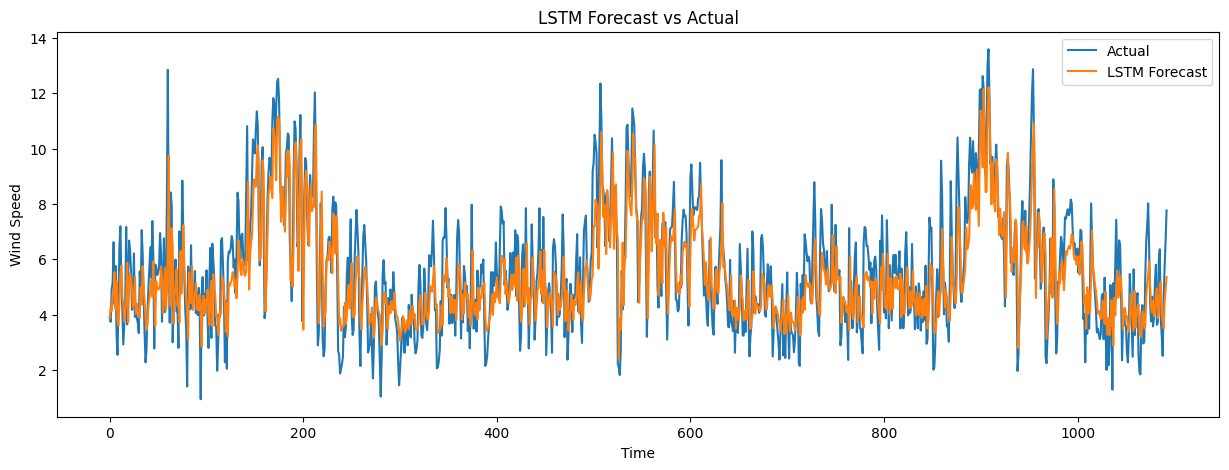

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

# Actual values
plt.plot(y_test_actual, label='Actual')

# Predicted values
plt.plot(lstm_predictions, label='LSTM Forecast')

plt.title('LSTM Forecast vs Actual')
plt.xlabel('Time')
plt.ylabel('Wind Speed')

plt.legend()

plt.show()

In [69]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_predictions))
mae = mean_absolute_error(y_test_actual, lstm_predictions)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 1.3681327069915448
MAE: 1.088567131352934


In [70]:
# Recreate full sequences

X_full = []
y_full = []

sequence_length = 30

for i in range(sequence_length, len(scaled_data)):
    X_full.append(scaled_data[i-sequence_length:i])
    y_full.append(scaled_data[i])

X_full = np.array(X_full)
y_full = np.array(y_full)

print(X_full.shape)

(10927, 30, 1)


In [71]:
# Build final model

final_lstm = Sequential()

final_lstm.add(
    LSTM(
        units=64,
        return_sequences=False,
        input_shape=(X_full.shape[1], 1)
    )
)

final_lstm.add(Dropout(0.2))

final_lstm.add(Dense(1))

final_lstm.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Train
final_lstm.fit(
    X_full,
    y_full,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0270
Epoch 2/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0154
Epoch 3/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0126
Epoch 4/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0117
Epoch 5/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0115
Epoch 6/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0116
Epoch 7/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0110
Epoch 8/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0110
Epoch 9/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0112
Epoch 10/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0110
Epoch 11/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0112
Epoch 12/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0110
Epoch 13/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0108
Epoch 14/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0108
Epoch 15/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0107


In [72]:
# Last 30 scaled values

current_sequence = scaled_data[-30:]

print(current_sequence.shape)

(30, 1)


In [78]:
from tqdm import tqdm

future_predictions_lstm = []

future_days = 4380

for _ in tqdm(range(future_days), desc="Predicting Future Values"):

    # Reshape for LSTM
    x_input = current_sequence.reshape(1, 30, 1)

    # Predict next value
    next_pred = final_lstm.predict(
        x_input,
        verbose=0
    )[0][0]

    # Store prediction
    future_predictions_lstm.append(next_pred)

    # Update sequence
    current_sequence = np.append(
        current_sequence[1:],
        [[next_pred]],
        axis=0
    )

Predicting Future Values: 100%|██████████| 4380/4380 [05:44<00:00, 12.72it/s]


In [79]:
future_predictions_lstm = scaler.inverse_transform(
    np.array(future_predictions_lstm).reshape(-1,1)
)

In [80]:
future_dates = pd.date_range(
    start='2015-01-01',
    periods=future_days,
    freq='D'
)

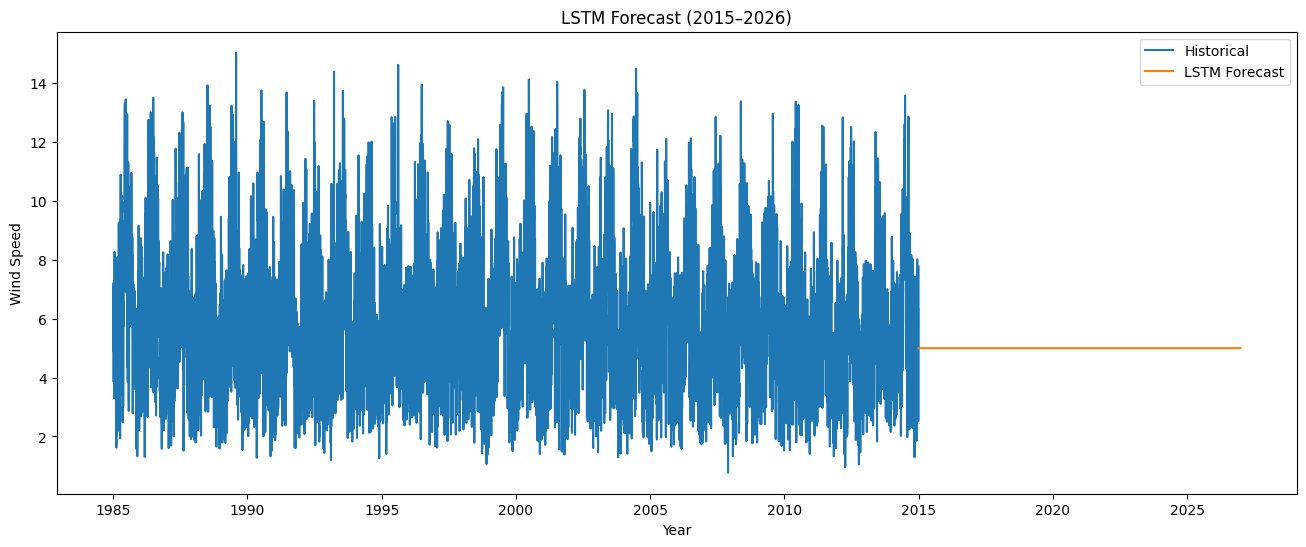

In [81]:
plt.figure(figsize=(16,6))

# Historical data
plt.plot(
    daily_df.index,
    daily_df.values,
    label='Historical'
)

# Future forecast
plt.plot(
    future_dates,
    future_predictions_lstm,
    label='LSTM Forecast'
)

plt.title('LSTM Forecast (2015–2026)')
plt.xlabel('Year')
plt.ylabel('Wind Speed')

plt.legend()

plt.show()

#### PatchTST

In [82]:
!pip install neuralforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.0/287.0 kB 6.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.2/447.2 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: tornado
    Found existing installation: tornado 6.5.1
    Uninstalling tornado-6.5.1:
      Successfully uninstalled tornado-6.5.1
  Attempting uninstall: pytorch-lightning
    Found existing installation: pytorch-lightning 2.6.1
    Uninstalling pytorch-lightning-2.6.1:
      Successfully uninstalled pytorch-lightning-2.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency

In [83]:
# Prepare daily data

transformer_df = daily_df.reset_index()

transformer_df.columns = ['ds', 'y']

# Add unique_id
transformer_df['unique_id'] = 'wind'

# Reorder columns
transformer_df = transformer_df[
    ['unique_id', 'ds', 'y']
]

print(transformer_df.head())

  unique_id         ds         y
0      wind 1985-01-01  3.889954
1      wind 1985-01-02  5.870372
2      wind 1985-01-03  5.891763
3      wind 1985-01-04  4.888502
4      wind 1985-01-05  5.555732


In [84]:
train_transformer = transformer_df[
    transformer_df['ds'] < '2014-01-01'
]

test_transformer = transformer_df[
    transformer_df['ds'] >= '2014-01-01'
]

print(train_transformer.shape)
print(test_transformer.shape)

(10592, 3)
(365, 3)


In [85]:
from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST

In [89]:
import torch

patchtst_model = PatchTST(
    h=365,
    input_size=365,
    patch_len=16,
    stride=8,
    hidden_size=64,
    n_heads=4,
    max_steps=500,
    batch_size=32,
    learning_rate=1e-3,

    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1
)

Seed set to 1


In [90]:
nf = NeuralForecast(
    models=[patchtst_model],
    freq='D'
)

In [91]:
nf.fit(df=train_transformer)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 1.2 M  | train
-----------------------------------------------------------
1.2 M     Trainable params
3         Non-trainable params
1.2 M     Total params
4.822     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=500` reached.


In [92]:
# Generate forecasts

transformer_forecast = nf.predict()

print(transformer_forecast.head())

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

  unique_id         ds  PatchTST
0      wind 2014-01-01  5.368943
1      wind 2014-01-02  3.981469
2      wind 2014-01-03  4.595697
3      wind 2014-01-04  4.429955
4      wind 2014-01-05  5.015802


In [93]:
# Reset index for actual data
actual_2014 = test_transformer.reset_index(drop=True)

# Reset forecast index
forecast_2014 = transformer_forecast.reset_index(drop=True)

print(actual_2014.head())
print(forecast_2014.head())

  unique_id         ds         y
0      wind 2014-01-01  8.783382
1      wind 2014-01-02  7.411379
2      wind 2014-01-03  4.665877
3      wind 2014-01-04  4.163873
4      wind 2014-01-05  3.405322
  unique_id         ds  PatchTST
0      wind 2014-01-01  5.368943
1      wind 2014-01-02  3.981469
2      wind 2014-01-03  4.595697
3      wind 2014-01-04  4.429955
4      wind 2014-01-05  5.015802


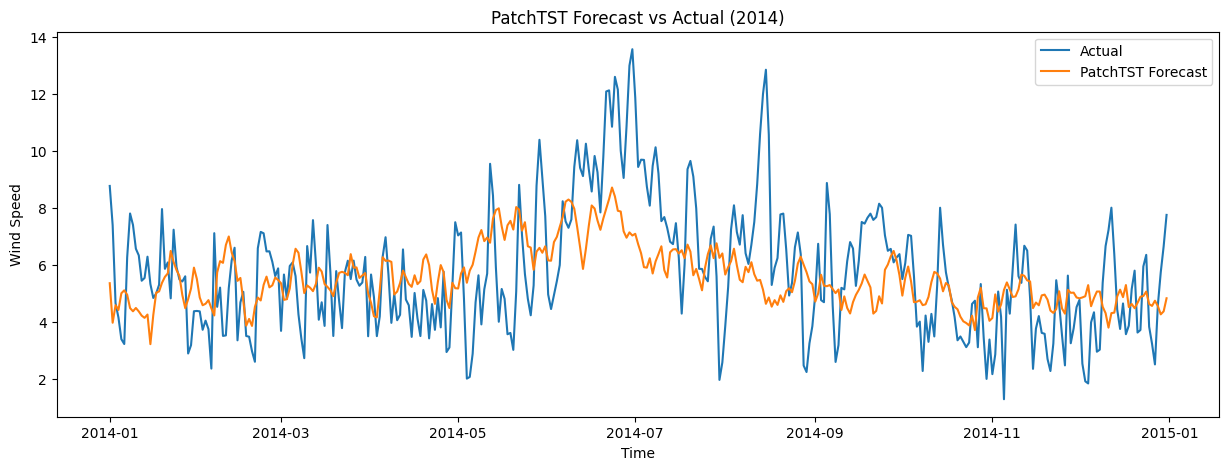

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

# Actual values
plt.plot(
    actual_2014['ds'],
    actual_2014['y'],
    label='Actual'
)

# Transformer predictions
plt.plot(
    forecast_2014['ds'],
    forecast_2014['PatchTST'],
    label='PatchTST Forecast'
)

plt.title('PatchTST Forecast vs Actual (2014)')
plt.xlabel('Time')
plt.ylabel('Wind Speed')

plt.legend()

plt.show()

In [95]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        actual_2014['y'],
        forecast_2014['PatchTST']
    )
)

mae = mean_absolute_error(
    actual_2014['y'],
    forecast_2014['PatchTST']
)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 2.017443260956691
MAE: 1.589253583806324


In [96]:
# Full dataset for transformer

full_transformer_df = transformer_df.copy()

print(full_transformer_df.shape)

(10957, 3)


In [97]:
from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST

# Final PatchTST model

final_patchtst = PatchTST(
    h=365,
    input_size=365,
    patch_len=16,
    stride=8,
    hidden_size=64,
    n_heads=4,
    max_steps=500,
    batch_size=32,
    learning_rate=1e-3,

    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1
)

Seed set to 1


In [98]:
final_nf = NeuralForecast(
    models=[final_patchtst],
    freq='D'
)

In [99]:
final_nf.fit(df=full_transformer_df)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name         | Type              | Params | Mode 
-----------------------------------------------------------
0 | loss         | MAE               | 0      | train
1 | padder_train | ConstantPad1d     | 0      | train
2 | scaler       | TemporalNorm      | 0      | train
3 | model        | PatchTST_backbone | 1.2 M  | train
-----------------------------------------------------------
1.2 M     Trainable params
3         Non-trainable params
1.2 M     Total params
4.822     Total estimated model params size (MB)
90        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=500` reached.


In [100]:
future_transformer_forecast = final_nf.predict()

print(future_transformer_forecast.head())
print(future_transformer_forecast.tail())

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

  unique_id         ds  PatchTST
0      wind 2015-01-01  6.851786
1      wind 2015-01-02  5.145640
2      wind 2015-01-03  5.010494
3      wind 2015-01-04  4.217143
4      wind 2015-01-05  4.154358
    unique_id         ds  PatchTST
360      wind 2015-12-27  5.834580
361      wind 2015-12-28  4.652826
362      wind 2015-12-29  5.193624
363      wind 2015-12-30  5.688667
364      wind 2015-12-31  6.001282


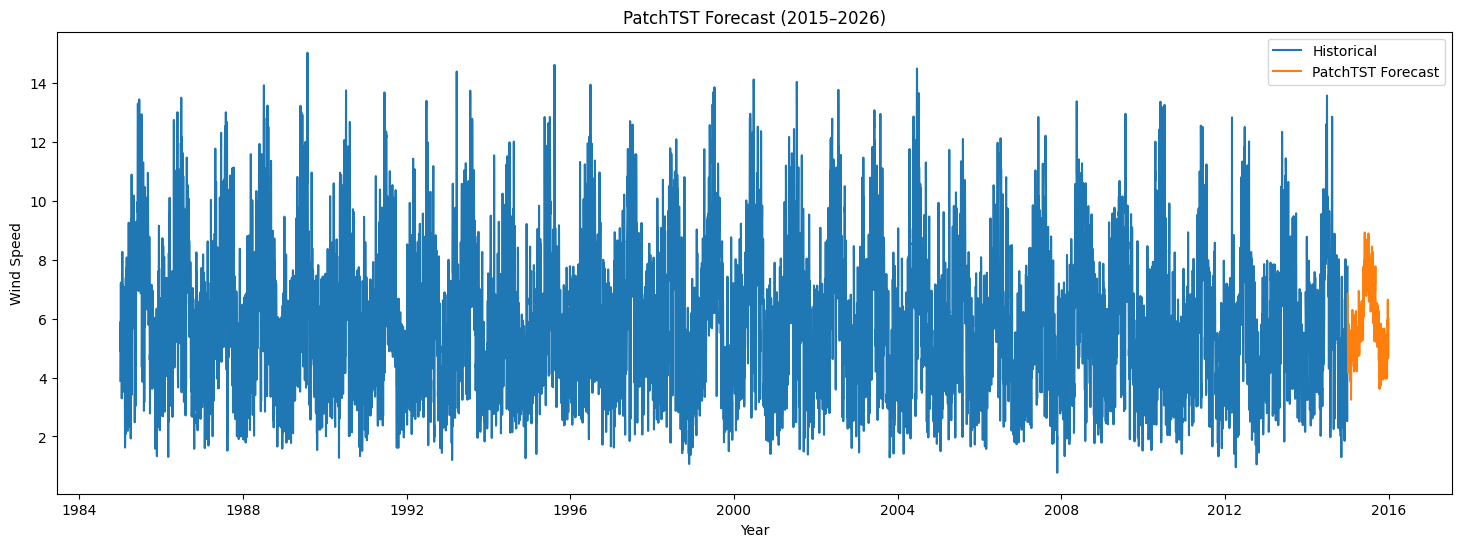

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,6))

# Historical data
plt.plot(
    transformer_df['ds'],
    transformer_df['y'],
    label='Historical'
)

# Future forecast
plt.plot(
    future_transformer_forecast['ds'],
    future_transformer_forecast['PatchTST'],
    label='PatchTST Forecast'
)

plt.title('PatchTST Forecast (2015–2026)')
plt.xlabel('Year')
plt.ylabel('Wind Speed')

plt.legend()

plt.show()